# Employee attrition: cost, drivers, and retention economics

A 1,470-employee tech company loses 16.1% of its staff a year. This notebook
walks through the three questions the project answers:

1. **What does that attrition actually cost?** (component-based cost model)
2. **Where is it concentrated, and what drives it?** (EDA + predictive models)
3. **Which interventions pay for themselves?** (segment economics)

Data: [IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhash/ibm-hr-analytics-attrition-dataset)
— a public, synthetic dataset; see `data/README.md` for source and caveats.
The reusable logic lives in `src/attrition/`; this notebook is the guided tour.

In [1]:
import pandas as pd

from attrition import data as adata
from attrition import cost_model as cm
from attrition import modeling as am
from attrition import viz

viz.apply_style()
pd.set_option("display.width", 120)

## 1. Data quality

The dataset is clean by construction (it's synthetic), but three columns are
constant, `PerformanceRating` only takes two values, and there are no dates —
which shapes what we can and can't claim later.

In [2]:
raw = adata.load_raw()
for note in adata.quality_report(raw):
    print("-", note)

df = adata.clean(raw)
overall = df["AttritionFlag"].mean()
print(f"\nAfter cleaning: {df.shape[0]} rows x {df.shape[1]} cols | "
      f"attrition {overall:.1%}")

- Rows: 1470, Columns: 35
- Missing values: 0
- Duplicate EmployeeNumber IDs: 0
- Constant (zero-information) columns: ['EmployeeCount', 'Over18', 'StandardHours']
- Rows with internally inconsistent tenure fields: 0
- PerformanceRating only takes values 3 and 4 — no low performers recorded, so it has almost no discriminative value.
- Single cross-sectional snapshot (synthetic, IBM-generated): no dates, so the 16.1% attrition is treated as an annualized rate for costing.

After cleaning: 1470 rows x 36 cols | attrition 16.1%


## 2. Where attrition concentrates

Attrition is not diffuse — it stacks up in overtime workers, first-year
employees, junior levels, and the bottom pay quartile.

In [3]:
for col in ["Department", "OverTime", "TenureBand", "JobLevel", "IncomeQuartile"]:
    print(f"=== {col} ===")
    print(adata.attrition_table(df, col, sort_by_rate=False).to_string(index=False))
    print()

=== Department ===
     Department  headcount  leavers  attrition_rate
    Engineering        961      133            13.8
Human Resources         63       12            19.0
          Sales        446       92            20.6

=== OverTime ===
OverTime  headcount  leavers  attrition_rate
      No       1054      110            10.4
     Yes        416      127            30.5

=== TenureBand ===
TenureBand  headcount  leavers  attrition_rate
    0-1 yr        215       75            34.9
   2-3 yrs        255       47            18.4
   4-6 yrs        382       49            12.8
  7-10 yrs        372       46            12.4
   10+ yrs        246       20             8.1

=== JobLevel ===
 JobLevel  headcount  leavers  attrition_rate
        1        543      143            26.3
        2        534       52             9.7
        3        218       32            14.7
        4        106        5             4.7
        5         69        5             7.2

=== IncomeQuartile ===


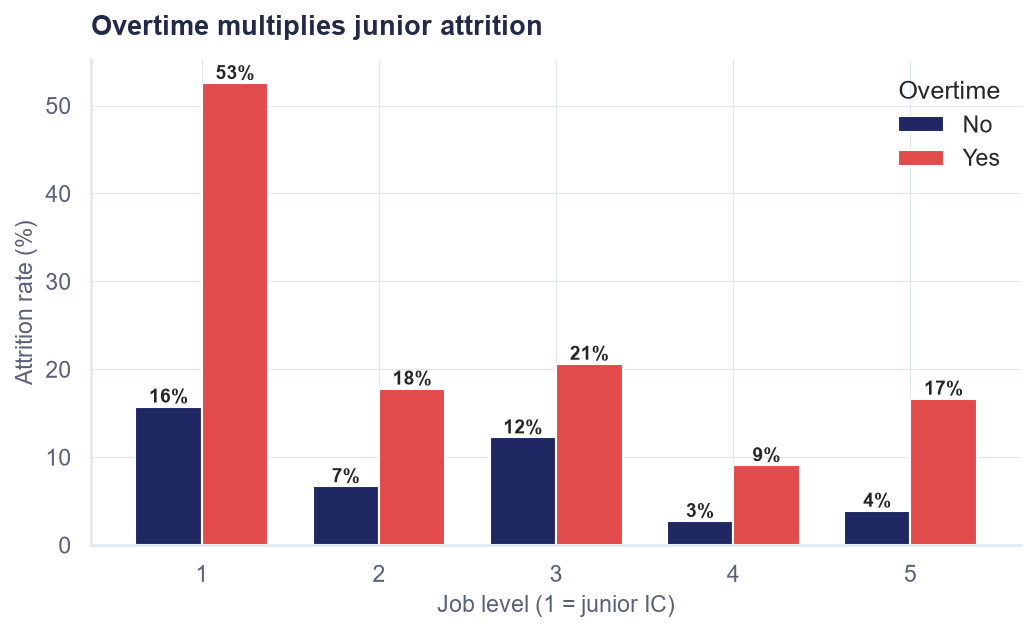

In [4]:
import matplotlib.pyplot as plt

pivot = (df.pivot_table(index="JobLevel", columns="OverTime",
                        values="AttritionFlag", aggfunc="mean") * 100)
fig, ax = plt.subplots(figsize=(8, 4.2))
pivot.plot(kind="bar", ax=ax, color=[viz.NAVY, viz.CORAL], width=0.75)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", fontsize=9, fontweight="bold")
ax.set_ylabel("Attrition rate (%)")
ax.set_xlabel("Job level (1 = junior IC)")
ax.set_title("Overtime multiplies junior attrition", loc="left", pad=12)
ax.legend(title="Overtime")
plt.setp(ax.get_xticklabels(), rotation=0)
plt.show()

The headline interaction: **junior (L1) employees working overtime leave at
52.6%** — 82 of the company's 237 annual departures from 156 people (11% of
headcount).

## 3. What a departure costs

Each departure is costed from four explicit components (recruiting 20% of
salary, onboarding 10%, vacancy months x salary, ramp months at 50%
productivity), tiered by job level. Full assumptions and benchmark anchors:
`src/attrition/cost_model.py`.

In [5]:
df = cm.apply_cost_model(df)
print(cm.unit_economics(df).to_string())
print()
summary = cm.annual_cost_summary(df)
print(f"Total annual attrition cost: ${summary['total_annual_cost']:,} "
      f"({summary['cost_pct_of_payroll']}% of payroll)")
print(f"Average per departure: ${summary['avg_cost_per_departure']:,} "
      f"= {summary['avg_cost_pct_of_salary']:.0%} of salary "
      f"(~{summary['avg_cost_pct_of_salary']*12:.1f} months)")

          headcount  median_annual_salary  avg_replacement_cost  cost_as_pct_of_salary
JobLevel                                                                              
1               543               32040.0               18394.0                   55.0
2               534               64080.0               39066.0                   59.0
3               218              119760.0               79520.0                   68.0
4               106              193848.0              148836.0                   80.0
5                69              230784.0              203433.0                   88.0

Total annual attrition cost: $8,674,901 (7.6% of payroll)
Average per departure: $36,603 = 59% of salary (~7.1 months)


Sanity check: ~59% of salary ≈ 7.1 months sits inside the SHRM 6–9-month
replacement rule of thumb and at the conservative end of Gallup's 0.5–2×
range — the model is defensible and, if anything, understates the loss.

Cost concentration in the risk segments:

In [6]:
segments = {
    "All overtime employees": df["OverTime"] == "Yes",
    "First-year employees": df["YearsAtCompany"] <= 1,
    "Junior + overtime core": (df["JobLevel"] == 1) & (df["OverTime"] == "Yes"),
}
print(pd.DataFrame(
    [{"segment": k, **cm.segment_cost(df, m)} for k, m in segments.items()]
).to_string(index=False))

               segment  headcount  leavers  attrition_rate_pct  annual_cost  pct_of_total_cost
All overtime employees        416      127                30.5      4551686               52.5
  First-year employees        215       75                34.9      1680858               19.4
Junior + overtime core        156       82                52.6      1415311               16.3


## 4. Predictive models

Logistic regression baseline vs XGBoost, stratified 75/25 split with 5-fold
CV. Given the 16% positive class we evaluate on ROC-AUC / PR-AUC and pick an
operating threshold that catches ≥70% of leavers (false positives are cheap
— a manager conversation; misses cost ~$37K).

In [7]:
result = am.train_and_evaluate(df.drop(columns=[
    c for c in df.columns
    if c.startswith("cost_") or c in (
        "annual_salary", "replacement_cost", "replacement_cost_pct_salary",
        "recruiting_pct_of_salary", "onboarding_pct_of_salary",
        "months_vacant", "ramp_months", "ramp_productivity_loss")
]))
result["metrics"][["model", "roc_auc", "pr_auc", "cv_roc_auc_mean",
                   "cv_roc_auc_std", "recall_at_op", "precision_at_op",
                   "flagged_employees"]]

,model,roc_auc,pr_auc,cv_roc_auc_mean,cv_roc_auc_std,recall_at_op,precision_at_op,flagged_employees
0,Logistic regression,0.810,0.562,0.842,0.044,0.712,0.35,120
1,XGBoost,0.785,0.522,0.813,0.033,0.712,0.35,120


The simpler model wins on this small, clean tabular dataset — reported
as-is rather than forcing the fancier model to look better. Both agree on
the drivers:

In [8]:
print("Top drivers, logistic regression (odds ratio per 1 SD):")
print(am.logreg_odds_ratios(result).head(10).to_string(index=False))

Top drivers, logistic regression (odds ratio per 1 SD):
                         feature  coef_per_sd  odds_ratio_per_sd
                    OverTime_Yes        0.692              1.998
BusinessTravel_Travel_Frequently        0.539              1.714
   JobRole_QA / Support Engineer        0.504              1.655
         YearsSinceLastPromotion        0.452              1.571
              NumCompaniesWorked        0.403              1.496
            MaritalStatus_Single        0.388              1.475
         EnvironmentSatisfaction       -0.366              0.693
            YearsWithCurrManager       -0.357              0.700
               TotalWorkingYears       -0.355              0.701
                 JobSatisfaction       -0.345              0.708


C:\Users\shalo\OneDrive\Desktop\attrition-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


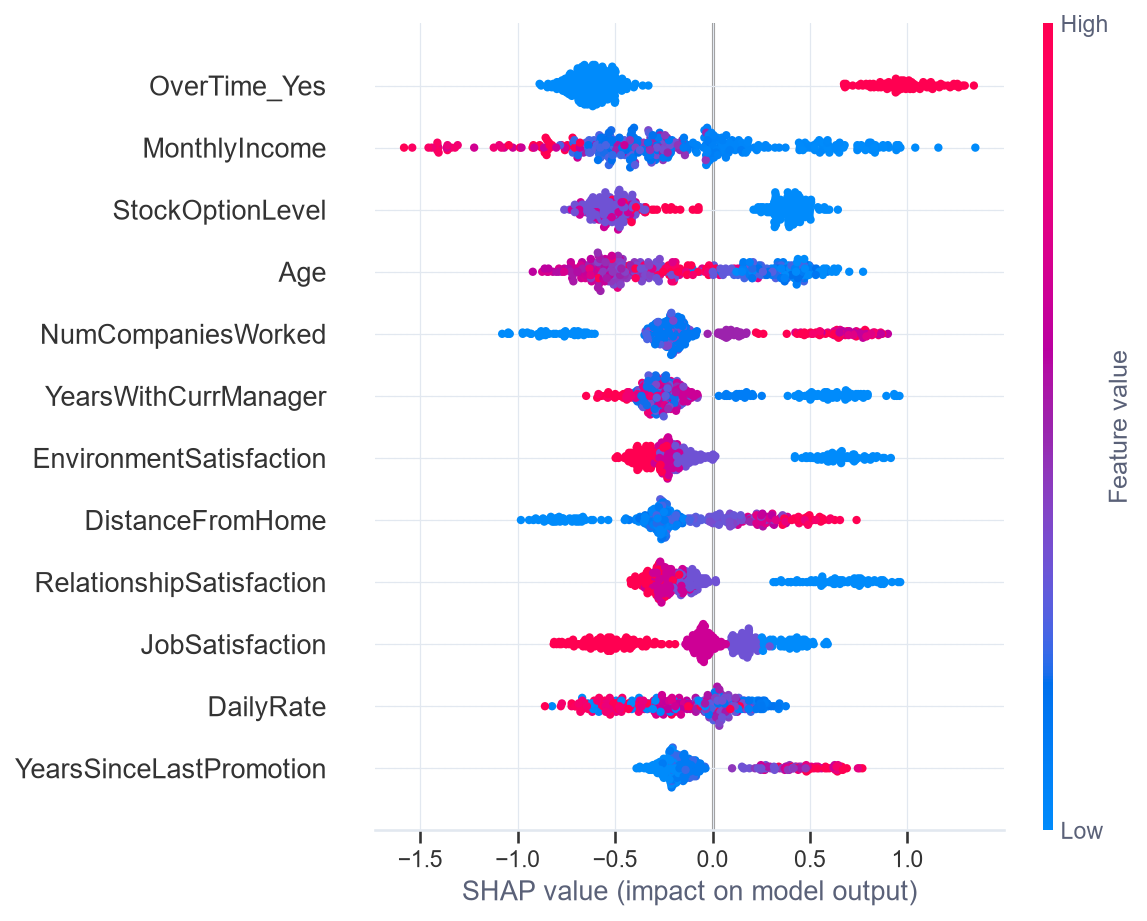

In [9]:
import shap

explainer = shap.TreeExplainer(result["models"]["XGBoost"])
shap_values = explainer.shap_values(result["X_test"])
shap.summary_plot(shap_values, result["X_test"], max_display=12)

One finding only the model surfaces: **years since last promotion raises
attrition risk (OR ≈ 1.6 per SD) once tenure is controlled for.** The raw
segment cut hides this because long-tenured employees have both stale
promotion dates and low attrition.

## 5. Takeaways

- Attrition costs **$8.67M/yr (7.6% of payroll)**; over half sits with the
  416 overtime employees.
- The recommended package (targeted overtime reduction + first-year
  experience program) projects **≈$1.25M/yr savings for ~$420K/yr cost** —
  see `reports/strategy_deck.md` for options, tradeoffs, and the pilot plan.
- A broad bottom-quartile pay raise does **not** pay for itself on
  replacement cost alone (−$640K/yr net) — the counterintuitive result that
  shapes the recommendation.

**Caveats** (full list in `outputs/model_report.md`): synthetic
cross-sectional data, correlation ≠ causation, no voluntary/involuntary
split, no market comp benchmarks. Intervention effect sizes are stated
assumptions to be validated by pilot, not model outputs.